# JaxFEM – Rechteckbalken 3D (HEX8)

Einfeldträger, gelenkig gelagert, gleichmäßige Streckenlast q auf Oberfläche.

| Parameter | Wert |
|-----------|------|
| Länge L   | 6,0 m |
| Breite b  | 0,3 m |
| Höhe h    | 0,5 m |
| Netz      | 100 × 20 × 1 (HEX8) |
| Material  | Stahl, E=210 000 kN/m², ν=0,3 |

Erzeugt von geobim.app FEM-Engineer, berechnet mit JaxFEM.

> ## JaxFEM API-Regeln (für Code-Generatoren / geobim.app)
>
> Diese Regeln verhindern bekannte Fehler beim Generieren von JaxFEM-Code:
>
> ### `jax_fem.logger_setup`
> - ❌ `logger_setup.setup()` — existiert **nicht**
> - ✅ `logger_setup.setup_logger('jax_fem')` — korrekte Funktion
>
> ### `jax_fem.generate_mesh.box_mesh`
> - Signatur: `box_mesh(Nx, Ny, Nz, domain_x, domain_y, domain_z)`
> - ❌ `box_mesh(Lx=..., Ly=..., Lz=...)` — falsche Parameter
> - ❌ `box_mesh(..., ele_type=...)` — kein `ele_type`-Parameter
> - ✅ `box_mesh(Nx=Nx, Ny=Ny, Nz=Nz, domain_x=Lx, domain_y=Ly, domain_z=Lz)`
>
> ### `jax_fem.generate_mesh.box_mesh_gmsh`
> - Signatur: `box_mesh_gmsh(Nx, Ny, Nz, domain_x, domain_y, domain_z, data_dir, ele_type='HEX8')`
> - Hat `ele_type`-Parameter (anders als `box_mesh`)
> - Benötigt `data_dir` (Verzeichnis für Gmsh-Ausgabe)
>
> ### Element-Typ
> - `get_meshio_cell_type(ele_type)` → gibt den meshio-Zelltyp zurück
> - HEX8-Netz: `ele_type = 'HEX8'`, dann `cell_type = get_meshio_cell_type(ele_type)`
> - Zellen: `meshio_mesh.cells_dict[cell_type]`
>
> ### Koordinatenachsen (3D-Balken)
> - x = Längsachse (Trägerlänge)
> - y = Breite
> - z = Höhe (Biegeachse) → Durchbiegung `uz`, Biegespannung `σ_xx`
> - Oberkante (Last): `z = Lz`
> - Unterkante (Auflager): `z = 0`

In [19]:
import jax
import jax.numpy as np
import numpy as onp
import matplotlib.pyplot as plt
from jax_fem.generate_mesh import Mesh
from jax_fem.problem import Problem
from jax_fem.solver import solver
from jax_fem import logger_setup

logger_setup.setup_logger('jax_fem')
print('JAX-Version:', jax.__version__)

JAX-Version: 0.6.2


## 1. Geometrie & Netz

Das Netz wird direkt aus den im generierten Code enthaltenen `points`- und `cells`-Arrays aufgebaut.

In [20]:
# ── Geometrieparameter ────────────────────────────────────
Lx = 6.0    # m – Trägerlänge (x)
Ly = 0.3    # m – Breite      (y)
Lz = 0.5    # m – Höhe        (z)
Nx = 100
Ny = 20
Nz = 1

from jax_fem.generate_mesh import box_mesh, get_meshio_cell_type

ele_type  = 'HEX8'
cell_type = get_meshio_cell_type(ele_type)

meshio_mesh = box_mesh(Nx=Nx, Ny=Ny, Nz=Nz,
                       domain_x=Lx, domain_y=Ly, domain_z=Lz)
mesh   = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
points = meshio_mesh.points

print(f'Netz: {len(points)} Knoten, {len(meshio_mesh.cells_dict[cell_type])} Elemente')
print(f'Δx={Lx/Nx:.3f} m  Δy={Ly/Ny:.4f} m  Δz={Lz/Nz:.3f} m')

Netz: 4242 Knoten, 2000 Elemente
Δx=0.060 m  Δy=0.0150 m  Δz=0.500 m


## 2. Material & Last

Materialparameter Stahl (Einheiten: kN + m).  
Streckenlast q auf der Oberfläche z = Lz (Oberkante).

In [21]:
# ── Material (Stahl, kN + m) ───────────────────────────────
E  = 210_000.0   # kN/m²
nu = 0.3
mu    = E / (2.0 * (1.0 + nu))
lmbda = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))

# ── Last ───────────────────────────────────────────────────
q = 10.0   # kN/m² – gleichmäßige Flächenlast auf Oberkante (z = Lz)

print(f'E={E:.0f} kN/m²  nu={nu}  q={q} kN/m²')
print(f'Analytische Auflagerreaktion RA = RB = {q*Ly*Lx/2:.2f} kN')

E=210000 kN/m²  nu=0.3  q=10.0 kN/m²
Analytische Auflagerreaktion RA = RB = 9.00 kN


## 3. Problem-Klasse (lineare Elastizität, 3D)

In [22]:
class LinearElasticity3D(Problem):
    """Lineare Elastizität, 3D (HEX8)."""

    def get_tensor_map(self):
        def stress(u_grad):
            epsilon = 0.5 * (u_grad + u_grad.T)
            sigma   = lmbda * np.trace(epsilon) * np.eye(self.dim) + 2.0 * mu * epsilon
            return sigma
        return stress

    def get_surface_maps(self):
        # Gleichmäßige Drucklast in -z-Richtung auf Oberkante
        def load_top(u, x):
            return np.array([0.0, 0.0, q])
        return [load_top]

## 4. Randbedingungen

| Auflager | Position | Typ | Gesperrt |
|----------|----------|-----|----------|
| A (Festlager) | x=0, z=0 | Gelenk | u_x, u_y, u_z |
| B (Loslager)  | x=L, z=0 | Gelenk | u_y, u_z |

Auflager werden auf der Unterkante (z=0) an den Trägerende-Linien modelliert.

In [23]:
tol = min(Lx/Nx, Ly/Ny, Lz/Nz) * 0.6

def zero(point):
    return 0.0

# Auflager A: x=0, z=0 → Festlager (u_x=u_y=u_z=0)
def at_A(point):
    return np.isclose(point[0], 0.0, atol=tol) & np.isclose(point[2], 0.0, atol=tol)

# Auflager B: x=Lx, z=0 → Loslager (u_y=u_z=0, u_x frei)
def at_B(point):
    return np.isclose(point[0], Lx, atol=tol) & np.isclose(point[2], 0.0, atol=tol)

# Oberkante: z=Lz → Neumann (Streckenlast)
def top_face(point):
    return np.isclose(point[2], Lz, atol=tol)

dirichlet_bc_info = [
    [at_A,  at_A,  at_A,  at_B,  at_B ],
    [0,     1,     2,     1,     2    ],
    [zero,  zero,  zero,  zero,  zero ],
]

location_fns = [top_face]

print('Randbedingungen definiert.')
print(f'  Dirichlet: {len(dirichlet_bc_info[0])}  |  Neumann: {len(location_fns)}')

Randbedingungen definiert.
  Dirichlet: 5  |  Neumann: 1


## 5. Lösen

In [24]:
problem = LinearElasticity3D(
    mesh=mesh,
    vec=3,
    dim=3,
    ele_type=ele_type,
    dirichlet_bc_info=dirichlet_bc_info,
    location_fns=location_fns,
)
sol = solver(problem, solver_options={'umfpack_solver': {}})
print('Lösung berechnet. Shape:', sol[0].shape)

[04-20 04:18:07][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[04-20 04:18:07][DEBUG] jax_fem: ele_type = HEX8, quad_points.shape = (num_quads, dim) = (8, 3)
[04-20 04:18:07][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (6, 4, 3)
[04-20 04:18:07][DEBUG] jax_fem: Done pre-computations, took 0.03282618522644043 [s]
[04-20 04:18:07][INFO] jax_fem: Solving a problem with 2000 cells, 4242x3 = 12726 dofs.
[04-20 04:18:07][INFO] jax_fem: Element type is HEX8, using 8 quad points per element.
[04-20 04:18:07][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[04-20 04:18:07][DEBUG] jax_fem: Start timing
[04-20 04:18:07][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[04-20 04:18:07][DEBUG] jax_fem: Function split_and_compute_cell took 0.0416 seconds
[04-20 04:18:07][DEBUG] jax_fem: Creating sparse matrix with scipy...
[04-20 04:18:07][DEBUG] jax_fem: Before, l_2 res = 0.39643442080626534, relative l_2

Lösung berechnet. Shape: (4242, 3)


## 6. Ergebnisse

### 6.1 Verschiebungen – Vergleich mit Balkenbiegeformel

FEM  w_max = -71.209 mm
Ana. w_max (EB)  = -77.143 mm
Abweichung       = 7.69 %
I = 0.003125 m⁴  q_lin = 3.00 kN/m
Überhöhungsfaktor: ×2


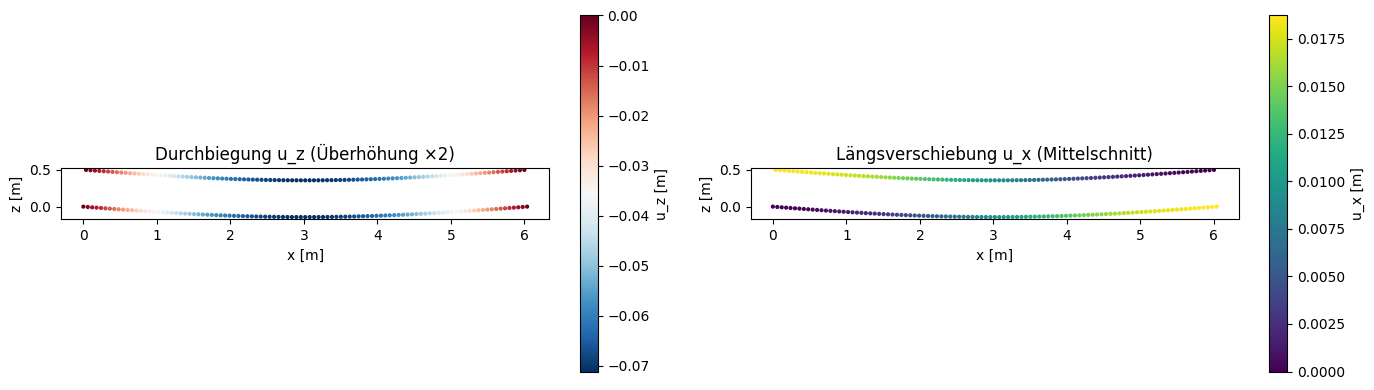

In [25]:
ux = onp.array(sol[0][:, 0])
uy = onp.array(sol[0][:, 1])
uz = onp.array(sol[0][:, 2])

w_fem = float(onp.min(uz))
print(f'FEM  w_max = {w_fem*1000:.3f} mm')

# Analytische Biegelinie: Einfeldträger mit gleichmäßiger Streckenlast
# q_total = q * Ly [kN/m], I = Ly * Lz³ / 12 [m⁴]
q_lin = q * Ly          # kN/m – Linienlast
I     = Ly * Lz**3 / 12
w_ana = -5.0 * q_lin * Lx**4 / (384.0 * E * I)
print(f'Ana. w_max (EB)  = {w_ana*1000:.3f} mm')
print(f'Abweichung       = {abs(w_fem - w_ana)/abs(w_ana)*100:.2f} %')
print(f'I = {I:.6f} m⁴  q_lin = {q_lin:.2f} kN/m')

# Überhöhungsfaktor für Plots
max_disp   = max(abs(w_fem), 1e-10)
scale      = min(0.3 * Lz / max_disp, 50.0)
scale      = max(round(scale, 0), 1.0)
print(f'Überhöhungsfaktor: ×{scale:.0f}')

# Verformte Geometrie (XZ-Ebene, Mitte y = Ly/2)
mask_mid_y = onp.abs(points[:, 1] - Ly/2) < (Ly/Ny) * 0.8
x_mid = points[mask_mid_y, 0]
z_mid = points[mask_mid_y, 2]
uz_mid = uz[mask_mid_y]
sort_xz = onp.argsort(x_mid + z_mid * 0.001)

x_def_3d = points[:, 0] + scale * ux
z_def_3d = points[:, 2] + scale * uz

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sc0 = axes[0].scatter(x_def_3d[mask_mid_y], z_def_3d[mask_mid_y],
                      c=uz_mid, cmap='RdBu_r', s=4)
plt.colorbar(sc0, ax=axes[0], label='u_z [m]')
axes[0].set_title(f'Durchbiegung u_z (Überhöhung ×{scale:.0f})')
axes[0].set_xlabel('x [m]'); axes[0].set_ylabel('z [m]')
axes[0].set_aspect('equal')

sc1 = axes[1].scatter(x_def_3d[mask_mid_y], z_def_3d[mask_mid_y],
                      c=ux[mask_mid_y], cmap='viridis', s=4)
plt.colorbar(sc1, ax=axes[1], label='u_x [m]')
axes[1].set_title('Längsverschiebung u_x (Mittelschnitt)')
axes[1].set_xlabel('x [m]'); axes[1].set_ylabel('z [m]')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

### 6.2 Spannungen (Gauss-Punkt-Extrapolation)

In [26]:
from scipy.spatial import cKDTree

def compute_stress_at_nodes_3d(problem, sol_array, points, cells):
    """Spannungen an Knoten via Gauss-Punkt-Extrapolation (HEX8, 2x2x2)."""
    gp = onp.array([-1/onp.sqrt(3), 1/onp.sqrt(3)])
    gp_triples = [(xi, eta, zeta) for xi in gp for eta in gp for zeta in gp]

    all_gp_coords = []
    all_sigma     = []

    for cell in cells:
        x_cell = points[cell]          # (8, 3)
        u_cell = sol_array[cell]       # (8, 3)

        for (xi, eta, zeta) in gp_triples:
            N = 0.125 * onp.array([
                (1-xi)*(1-eta)*(1-zeta),
                (1+xi)*(1-eta)*(1-zeta),
                (1+xi)*(1+eta)*(1-zeta),
                (1-xi)*(1+eta)*(1-zeta),
                (1-xi)*(1-eta)*(1+zeta),
                (1+xi)*(1-eta)*(1+zeta),
                (1+xi)*(1+eta)*(1+zeta),
                (1-xi)*(1+eta)*(1+zeta),
            ])
            dN_dxi = 0.125 * onp.array([
                [-(1-eta)*(1-zeta), -(1-xi)*(1-zeta), -(1-xi)*(1-eta)],
                [ (1-eta)*(1-zeta), -(1+xi)*(1-zeta), -(1+xi)*(1-eta)],
                [ (1+eta)*(1-zeta),  (1+xi)*(1-zeta), -(1+xi)*(1+eta)],
                [-(1+eta)*(1-zeta),  (1-xi)*(1-zeta), -(1-xi)*(1+eta)],
                [-(1-eta)*(1+zeta), -(1-xi)*(1+zeta),  (1-xi)*(1-eta)],
                [ (1-eta)*(1+zeta), -(1+xi)*(1+zeta),  (1+xi)*(1-eta)],
                [ (1+eta)*(1+zeta),  (1+xi)*(1+zeta),  (1+xi)*(1+eta)],
                [-(1+eta)*(1+zeta),  (1-xi)*(1+zeta),  (1-xi)*(1+eta)],
            ])

            J     = dN_dxi.T @ x_cell          # (3,3)
            Jinv  = onp.linalg.inv(J)
            dN_dx = dN_dxi @ Jinv.T            # (8,3)
            x_gp  = N @ x_cell                 # (3,)
            grad_u = dN_dx.T @ u_cell          # (3,3)

            eps = 0.5 * (grad_u + grad_u.T)
            tr_eps = onp.trace(eps)
            sig = lmbda * tr_eps * onp.eye(3) + 2 * mu * eps

            all_gp_coords.append(x_gp)
            all_sigma.append(sig.flatten())

    all_gp_coords = onp.array(all_gp_coords)
    all_sigma     = onp.array(all_sigma)

    tree = cKDTree(all_gp_coords)
    _, idx = tree.query(points)
    return all_sigma[idx].reshape(-1, 3, 3)


cells_hex = meshio_mesh.cells_dict[cell_type]
sigma_nd  = compute_stress_at_nodes_3d(problem, onp.array(sol[0]), points, cells_hex)

sxx = sigma_nd[:, 0, 0]
szz = sigma_nd[:, 2, 2]
sxz = sigma_nd[:, 0, 2]

# von-Mises (vereinfacht für dominante Spannungen)
syy = sigma_nd[:, 1, 1]
syz = sigma_nd[:, 1, 2]
sxy = sigma_nd[:, 0, 1]
s_vm = onp.sqrt(0.5 * ((sxx-syy)**2 + (syy-szz)**2 + (szz-sxx)**2
                        + 6*(sxy**2 + syz**2 + sxz**2)))

print(f'σ_xx: min={sxx.min():.1f}  max={sxx.max():.1f}  kN/m²')
print(f'σ_zz: min={szz.min():.1f}  max={szz.max():.1f}  kN/m²')
print(f'τ_xz: min={sxz.min():.1f}  max={sxz.max():.1f}  kN/m²')
print(f'von-Mises max = {s_vm.max():.1f}  kN/m²')

σ_xx: min=-620.5  max=620.5  kN/m²
σ_zz: min=-191.2  max=181.2  kN/m²
τ_xz: min=-136.9  max=137.8  kN/m²
von-Mises max = 554.5  kN/m²


### 6.3 Spannungs-Plots (Mittelschnitt y = Ly/2)

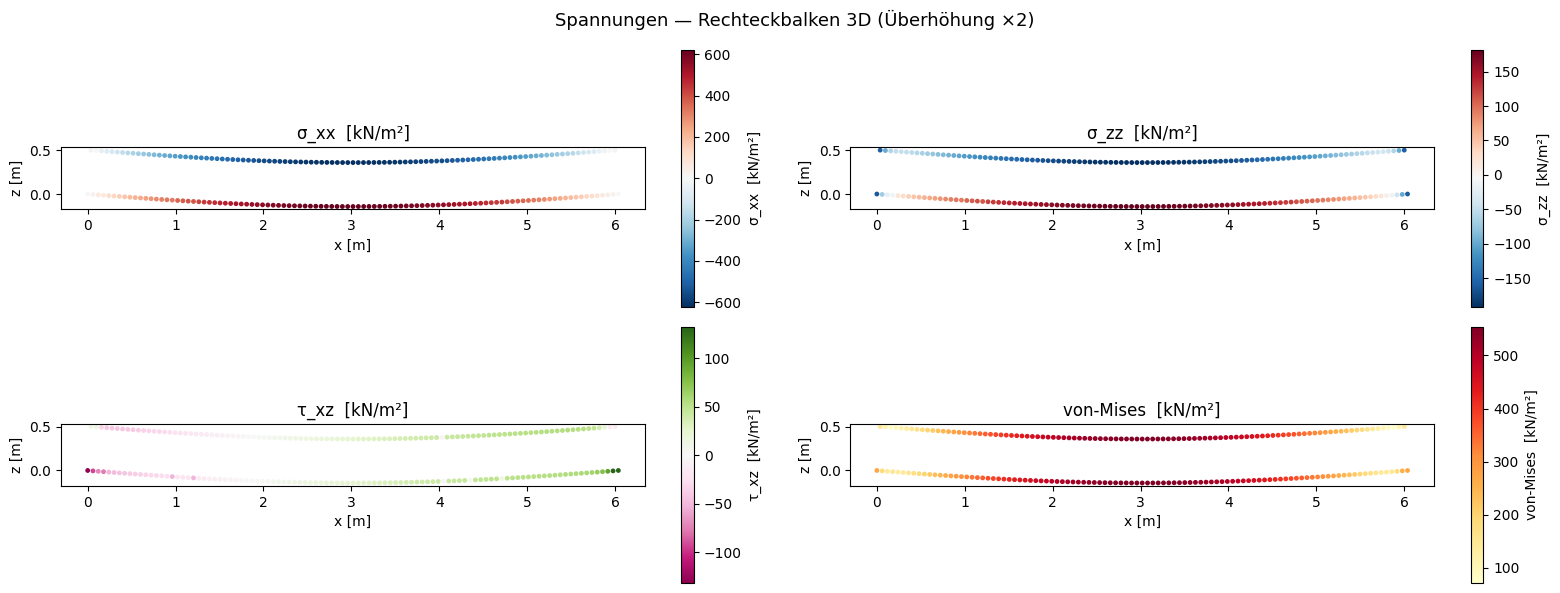

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 6))
axes = axes.flatten()

plots = [
    (sxx[mask_mid_y], 'σ_xx  [kN/m²]',      'RdBu_r'),
    (szz[mask_mid_y], 'σ_zz  [kN/m²]',      'RdBu_r'),
    (sxz[mask_mid_y], 'τ_xz  [kN/m²]',      'PiYG'),
    (s_vm[mask_mid_y], 'von-Mises  [kN/m²]', 'YlOrRd'),
]

for ax, (data, label, cmap) in zip(axes, plots):
    sc = ax.scatter(
        x_def_3d[mask_mid_y], z_def_3d[mask_mid_y],
        c=data, cmap=cmap, s=6
    )
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_title(label)
    ax.set_xlabel('x [m]'); ax.set_ylabel('z [m]')
    ax.set_aspect('equal')

plt.suptitle(f'Spannungen — Rechteckbalken 3D (Überhöhung ×{scale:.0f})', fontsize=13)
plt.tight_layout()
plt.show()

### 6.4 Schnittgrößen M, V, N (analytisch) + FEM-Biegelinie

Linienlast q_lin = 3.00 kN/m
RA = RB = 9.00 kN
M_max (Feldmitte) = 13.500 kNm


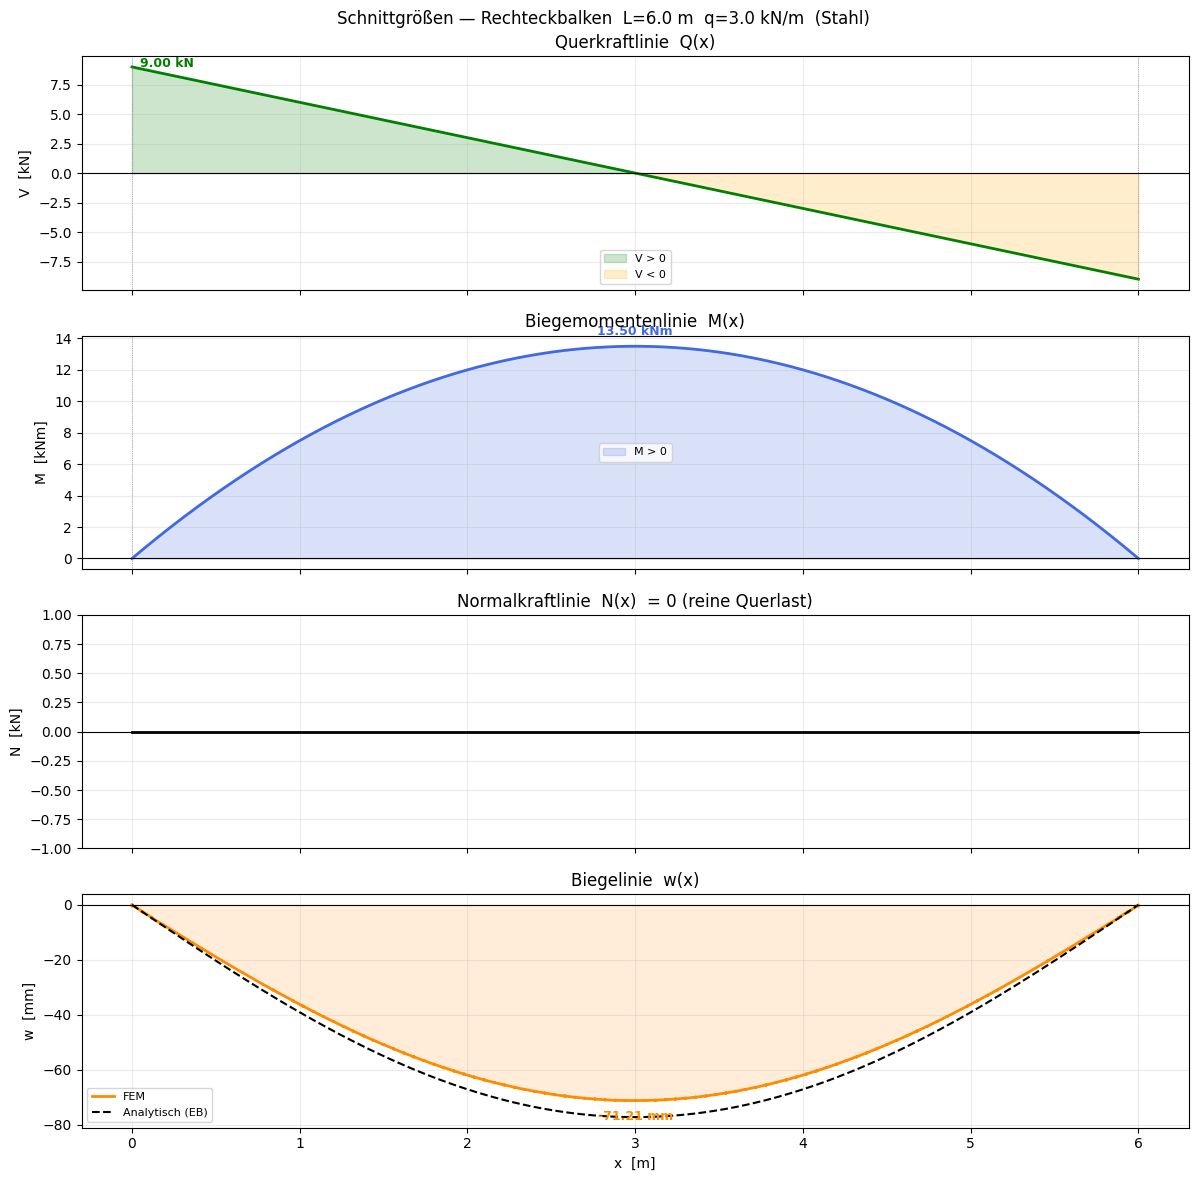

In [28]:
x_plot = onp.linspace(0, Lx, 1000)

# Linienlast [kN/m], Auflagerreaktionen
q_lin = q * Ly
RA    = q_lin * Lx / 2
RB    = q_lin * Lx / 2

M_vals = RA * x_plot - q_lin * x_plot**2 / 2
V_vals = RA - q_lin * x_plot
N_vals = onp.zeros_like(x_plot)

M_max = q_lin * Lx**2 / 8
print(f'Linienlast q_lin = {q_lin:.2f} kN/m')
print(f'RA = RB = {RA:.2f} kN')
print(f'M_max (Feldmitte) = {M_max:.3f} kNm')

# FEM-Biegelinie: mittlere Faser (z ≈ Lz/2)
tol_mid = (Lz / Nz) * 0.8
mask_zc = onp.abs(points[:, 2] - Lz/2) < tol_mid
x_bl    = points[mask_zc, 0]
w_bl    = uz[mask_zc]
sort_bl = onp.argsort(x_bl)
x_bl    = x_bl[sort_bl];  w_bl = w_bl[sort_bl]

# ── 4 Subplots ────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True,
                         gridspec_kw={'height_ratios': [1, 1, 1, 1]})
fig.suptitle(f'Schnittgrößen — Rechteckbalken  L={Lx} m  q={q_lin:.1f} kN/m  (Stahl)', fontsize=12)

# ① Querkraftlinie
ax = axes[0]
ax.plot(x_plot, V_vals, color='green', lw=2)
ax.fill_between(x_plot, 0, V_vals, where=(V_vals>=0), alpha=0.2, color='green', label='V > 0')
ax.fill_between(x_plot, 0, V_vals, where=(V_vals< 0), alpha=0.2, color='orange', label='V < 0')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0,  color='gray', lw=0.5, ls=':')
ax.axvline(Lx, color='gray', lw=0.5, ls=':')
ax.annotate(f'{V_vals[0]:.2f} kN', xy=(x_plot[0], V_vals[0]),
            xytext=(6,0), textcoords='offset points', fontsize=9, color='green', fontweight='bold')
ax.set_ylabel('V  [kN]'); ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
ax.set_title('Querkraftlinie  Q(x)')

# ② Biegemomentenlinie
ax = axes[1]
ax.plot(x_plot, M_vals, color='royalblue', lw=2)
ax.fill_between(x_plot, 0, M_vals, alpha=0.2, color='royalblue', label='M > 0')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0,  color='gray', lw=0.5, ls=':')
ax.axvline(Lx, color='gray', lw=0.5, ls=':')
i_max = onp.argmax(M_vals)
ax.annotate(f'{M_vals[i_max]:.2f} kNm', xy=(x_plot[i_max], M_vals[i_max]),
            xytext=(0,8), textcoords='offset points', ha='center',
            fontsize=9, color='royalblue', fontweight='bold')
ax.set_ylabel('M  [kNm]'); ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
ax.set_title('Biegemomentenlinie  M(x)')

# ③ Normalkraftlinie
ax = axes[2]
ax.plot(x_plot, N_vals, 'k-', lw=2)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylim(-1, 1); ax.set_ylabel('N  [kN]'); ax.grid(True, alpha=0.25)
ax.set_title('Normalkraftlinie  N(x)  = 0 (reine Querlast)')

# ④ Biegelinie (FEM)
ax = axes[3]
ax.plot(x_bl, w_bl * 1000, color='darkorange', lw=2, label='FEM')
# Analytische Biegelinie
x_a    = onp.linspace(0, Lx, 500)
w_a    = -q_lin * x_a * (Lx**3 - 2*Lx*x_a**2 + x_a**3) / (24 * E * I)
ax.plot(x_a, w_a * 1000, 'k--', lw=1.5, label='Analytisch (EB)')
ax.axhline(0, color='black', lw=0.8)
ax.fill_between(x_bl, 0, w_bl*1000, alpha=0.15, color='darkorange')
i_w = onp.argmin(w_bl)
ax.annotate(f'{w_bl[i_w]*1000:.2f} mm', xy=(x_bl[i_w], w_bl[i_w]*1000),
            xytext=(0,-14), textcoords='offset points', ha='center',
            fontsize=9, color='darkorange', fontweight='bold')
ax.set_ylabel('w  [mm]'); ax.set_xlabel('x  [m]')
ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
ax.set_title('Biegelinie  w(x)')

plt.tight_layout()
plt.show()

### 6.5 Biegespannungsverteilung σ_xx über Querschnittshöhe (FEM vs. EB)

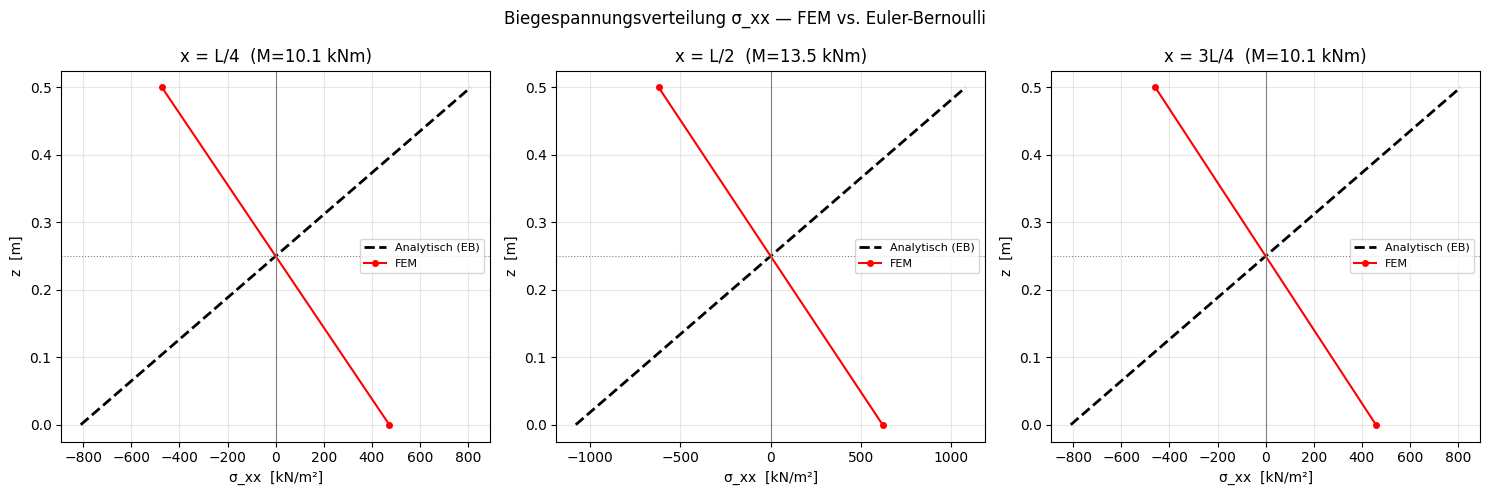

In [29]:
z_neutral = Lz / 2
tol_x_cut = (Lx / Nx) * 0.8

x_cuts = {
    'x = L/4': Lx / 4,
    'x = L/2': Lx / 2,
    'x = 3L/4': 3 * Lx / 4,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (label, x_cut) in zip(axes, x_cuts.items()):
    mask_x = (onp.abs(points[:, 0] - x_cut) < tol_x_cut) & mask_mid_y
    z_fem  = points[mask_x, 2]
    sxx_s  = sxx[mask_x]
    sort_i = onp.argsort(z_fem)

    M_ana     = RA * x_cut - q_lin * x_cut**2 / 2
    z_vals    = onp.linspace(0, Lz, 200)
    sigma_ana = M_ana * (z_vals - z_neutral) / I

    ax.plot(sigma_ana, z_vals, 'k--', lw=2, label='Analytisch (EB)')
    ax.plot(sxx_s[sort_i], z_fem[sort_i], 'ro-', ms=4, label='FEM')
    ax.axvline(0, color='gray', lw=0.8)
    ax.axhline(z_neutral, color='gray', lw=0.8, ls=':')
    ax.set_xlabel('σ_xx  [kN/m²]')
    ax.set_ylabel('z  [m]')
    ax.set_title(f'{label}  (M={M_ana:.1f} kNm)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Biegespannungsverteilung σ_xx — FEM vs. Euler-Bernoulli', fontsize=12)
plt.tight_layout()
plt.show()